In [33]:
from langgraph.graph import MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [34]:
load_dotenv()

True

In [35]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [36]:
class ChatState(MessagesState):
    summary: str

In [37]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [38]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [39]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [40]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [41]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

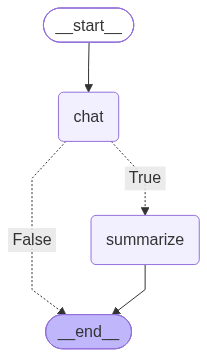

In [42]:
graph

In [43]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [44]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        tpm=type(m).__name__
        if(tpm=="AIMessage"):
            print("-", type(m).__name__, ":", m.text[:80])
            continue
        print("-", type(m).__name__, ":", m.content[:80])

In [45]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8a10b3e1-b26d-4710-b477-f325447e49b4')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : **Quantum Physics in a Nutshell**

Quantum physics (or quantum mechanics) is the


In [46]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8a10b3e1-b26d-4710-b477-f325447e49b4'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and sub‑atomic particles. It replaces classical ideas like “particles move in neat orbits” with a probabilistic, wave‑like framework that has been confirmed by countless experiments.\n\n---\n\n### 1. Core Principles\n\n| Principle | What it Means | Why It Matters |\n|-----------|---------------|----------------|\n| **Wave–Particle Duality** | Light and matter exhibit both particle and wave properties. | Explains phenomena such as interference, diffraction, and the photoelectric effect. |\n| **Quantization** | Physical quantities (energy, angular momentum, etc.) come in discrete “quanta.” | Accounts for atomic spectra, stability of atoms, and th

In [47]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8a10b3e1-b26d-4710-b477-f325447e49b4'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and sub‑atomic particles. It replaces classical ideas like “particles move in neat orbits” with a probabilistic, wave‑like framework that has been confirmed by countless experiments.\n\n---\n\n### 1. Core Principles\n\n| Principle | What it Means | Why It Matters |\n|-----------|---------------|----------------|\n| **Wave–Particle Duality** | Light and matter exhibit both particle and wave properties. | Explains phenomena such as interference, diffraction, and the photoelectric effect. |\n| **Quantization** | Physical quantities (energy, angular momentum, etc.) come in discrete “quanta.” | Accounts for atomic spectra, stability of atoms, and th

In [48]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8a10b3e1-b26d-4710-b477-f325447e49b4'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and sub‑atomic particles. It replaces classical ideas like “particles move in neat orbits” with a probabilistic, wave‑like framework that has been confirmed by countless experiments.\n\n---\n\n### 1. Core Principles\n\n| Principle | What it Means | Why It Matters |\n|-----------|---------------|----------------|\n| **Wave–Particle Duality** | Light and matter exhibit both particle and wave properties. | Explains phenomena such as interference, diffraction, and the photoelectric effect. |\n| **Quantization** | Physical quantities (energy, angular momentum, etc.) come in discrete “quanta.” | Accounts for atomic spectra, stability of atoms, and th